In [1]:
# Hands-on Project: Handwritten Digit Classification using Neural Networks

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8887 - loss: 0.4026 - val_accuracy: 0.9370 - val_loss: 0.2206
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9469 - loss: 0.1898 - val_accuracy: 0.9563 - val_loss: 0.1591
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1397 - val_accuracy: 0.9607 - val_loss: 0.1330
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.1090 - val_accuracy: 0.9643 - val_loss: 0.1194
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9741 - loss: 0.0885 - val_accuracy: 0.9665 - val_loss: 0.1098
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9680 - loss: 0.1086
Accuracy: 0.9679999947547913
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


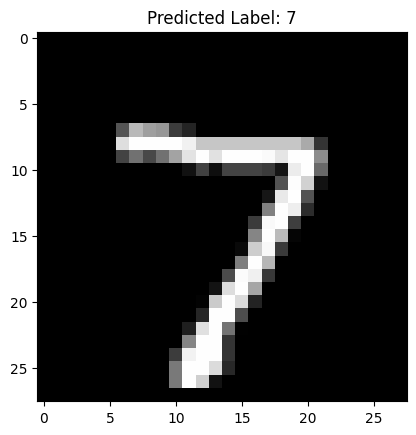

In [10]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Preprocess the data by normalizing the pixel values and reshaping the input
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# Define/Build the neural network architecture, using at least one hidden layer and an output layer for 10-class classification
model = Sequential()
model.add(Flatten(input_shape=(28,28,1)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Train/compile the model and monitor the accuracy and loss during training
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

# Evaluate the model on the test dataset and visualize some predictions
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {test_accuracy}")

# make predictions on the test data
import numpy as np
import matplotlib.pyplot as plt
predictions = model.predict(X_test)
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.show()